<a href="https://colab.research.google.com/github/senchiao/HRRR_plots/blob/main/ATMS340_week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. Python coding

In this practice you learn how to read in a netcdf file and plot certain variables from this file.

In [ ]:
# now we can start with python coding
# python is based on different packages which we upload first

!pip install netCDF4
!pip install basemap
!pip install cartopy

import numpy as np              # Numpy is the fundamental package for scientific computing in Python.
import netCDF4 as nc            # NetCDF is the data format of the meteorological data that we use.
import matplotlib.pyplot as pl  # Matplotlib is a scientific plotting package.
from mpl_toolkits.basemap import Basemap # Import the map plotting interface.
import cartopy.crs as ccrs # cartographic coordinate reference system
import cartopy.feature as cfeature # features such as land, borders, coastlines

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 98.3 MB/s eta 0:00:00


During this course we will study the dynamics by analysing data from a re-analysis dataset. Re-analysis  is a climate or weather model simulation of the past that includes data assimilation of historical observations.
The dataset used here is called Era-Interim and is produced at the European Centre for Medium Range Forecasting. It is freely available, and provided in netcdf format, which is a common format in climate science.

We have provided a dataset from ERA-Interim from one particular day.
You can read in a dataset in python in the following way:    

The file, test.nc, is at https://drive.google.com/file/d/1_iQNZV1Tb7RteXnkzN5rLJSpMOCUi9gd/view?usp=sharing

In [ ]:
nc_file = nc.Dataset("sample_data/test.nc", "r")  # read in netcdf file
lat = nc_file.variables["latitude"][:]     # upload latitude
lon = nc_file.variables["longitude"][:]    # upload longitude
p = nc_file.variables["level"][:]*100      # upload level (in mbars = hPa) *100 to transform it into Pa
Temp = nc_file.variables["t"][:,:,:,:]     # upload variable temperature [time, level, latitude, longitude]

nc_file.close() # close the file

another way to read data via google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
nc_file = nc.Dataset("/content/drive/MyDrive/Colab Notebooks/test.nc", "r")  # read in netcdf file
nc_file.variables.keys()


dict_keys(['longitude', 'latitude', 'level', 'time', 'z', 't', 'w', 'u', 'v'])

In [ ]:
uu = nc_file.variables["u"][:,:,:,:]     # upload variable temperature [time, level, latitude, longitude]
ww = nc_file.variables["w"][:,:,:,:]     # upload variable temperature [time, level, latitude, longitude]
vv = nc_file.variables["v"][:,:,:,:]     # upload variable temperature [time, level, latitude, longitude]
tt = nc_file.variables["t"][:,:,:,:]     # upload variable temperature [time, level, latitude, longitude]
lat = nc_file.variables["latitude"][:]     # upload latitude
lon = nc_file.variables["longitude"][:]    # upload longitude
nc_file.close() # close the file

Next line is to print out the value of u

In [ ]:
uu

masked_array(
  data=[[[[-4.08632321e+00, -4.00352427e+00, -3.92417530e+00, ...,
           -4.32092018e+00, -4.24502116e+00, -4.16567218e+00],
          [-5.00056143e+00, -4.90051272e+00, -4.80391396e+00, ...,
           -5.29380765e+00, -5.19720890e+00, -5.10061014e+00],
          [-5.45940552e+00, -5.35245690e+00, -5.24205832e+00, ...,
           -5.79060125e+00, -5.68020267e+00, -5.56980410e+00],
          ...,
          [-5.05231076e+00, -5.00401139e+00, -4.95226205e+00, ...,
           -5.19720890e+00, -5.14890952e+00, -5.10061014e+00],
          [-4.61071645e+00, -4.57621690e+00, -4.54171734e+00, ...,
           -4.71076516e+00, -4.67971556e+00, -4.64521601e+00],
          [-4.06217352e+00, -4.04147378e+00, -4.02077405e+00, ...,
           -4.12427272e+00, -4.10357298e+00, -4.08287325e+00]],

         [[-3.44463147e+00, -3.35493263e+00, -3.26178383e+00, ...,
           -3.71027805e+00, -3.62402916e+00, -3.53433032e+00],
          [-4.39681921e+00, -4.28297067e+00, -4.16912214e+0

plot zonal wind. dpi is the size of the plot. you can change the value and see the differences.

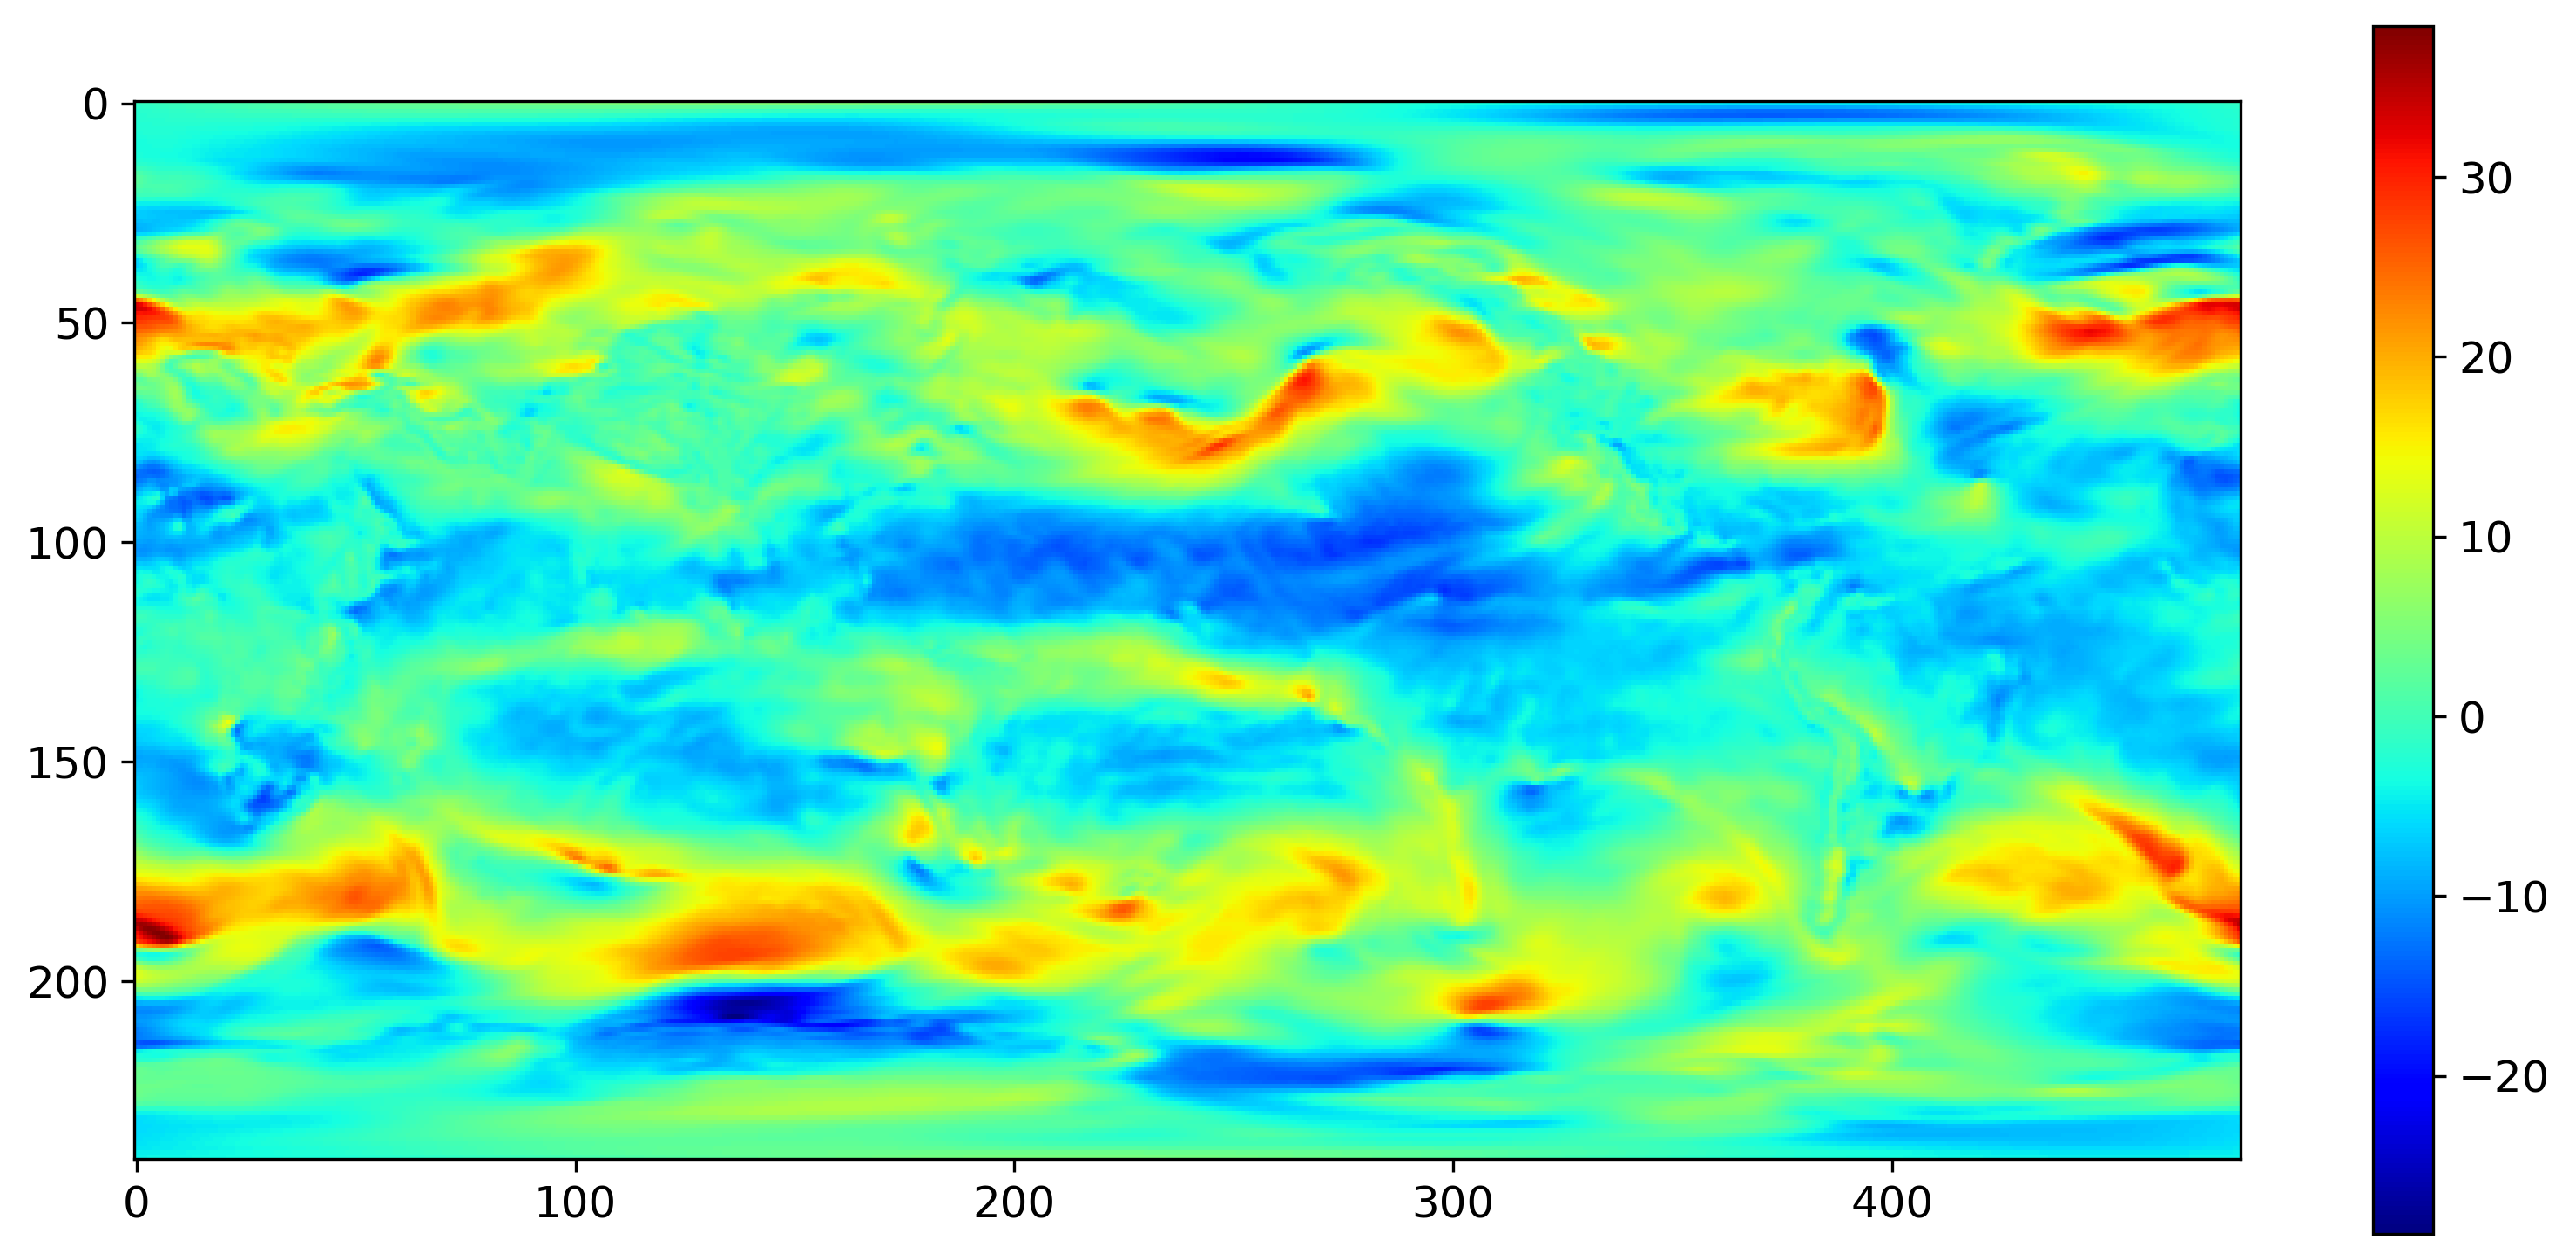

In [ ]:
pl.figure(dpi=300)
pl.imshow(uu[t, n, :, :], cmap='jet')
pl.colorbar()

**Q1: can you fix this following block for vertical velocity?**

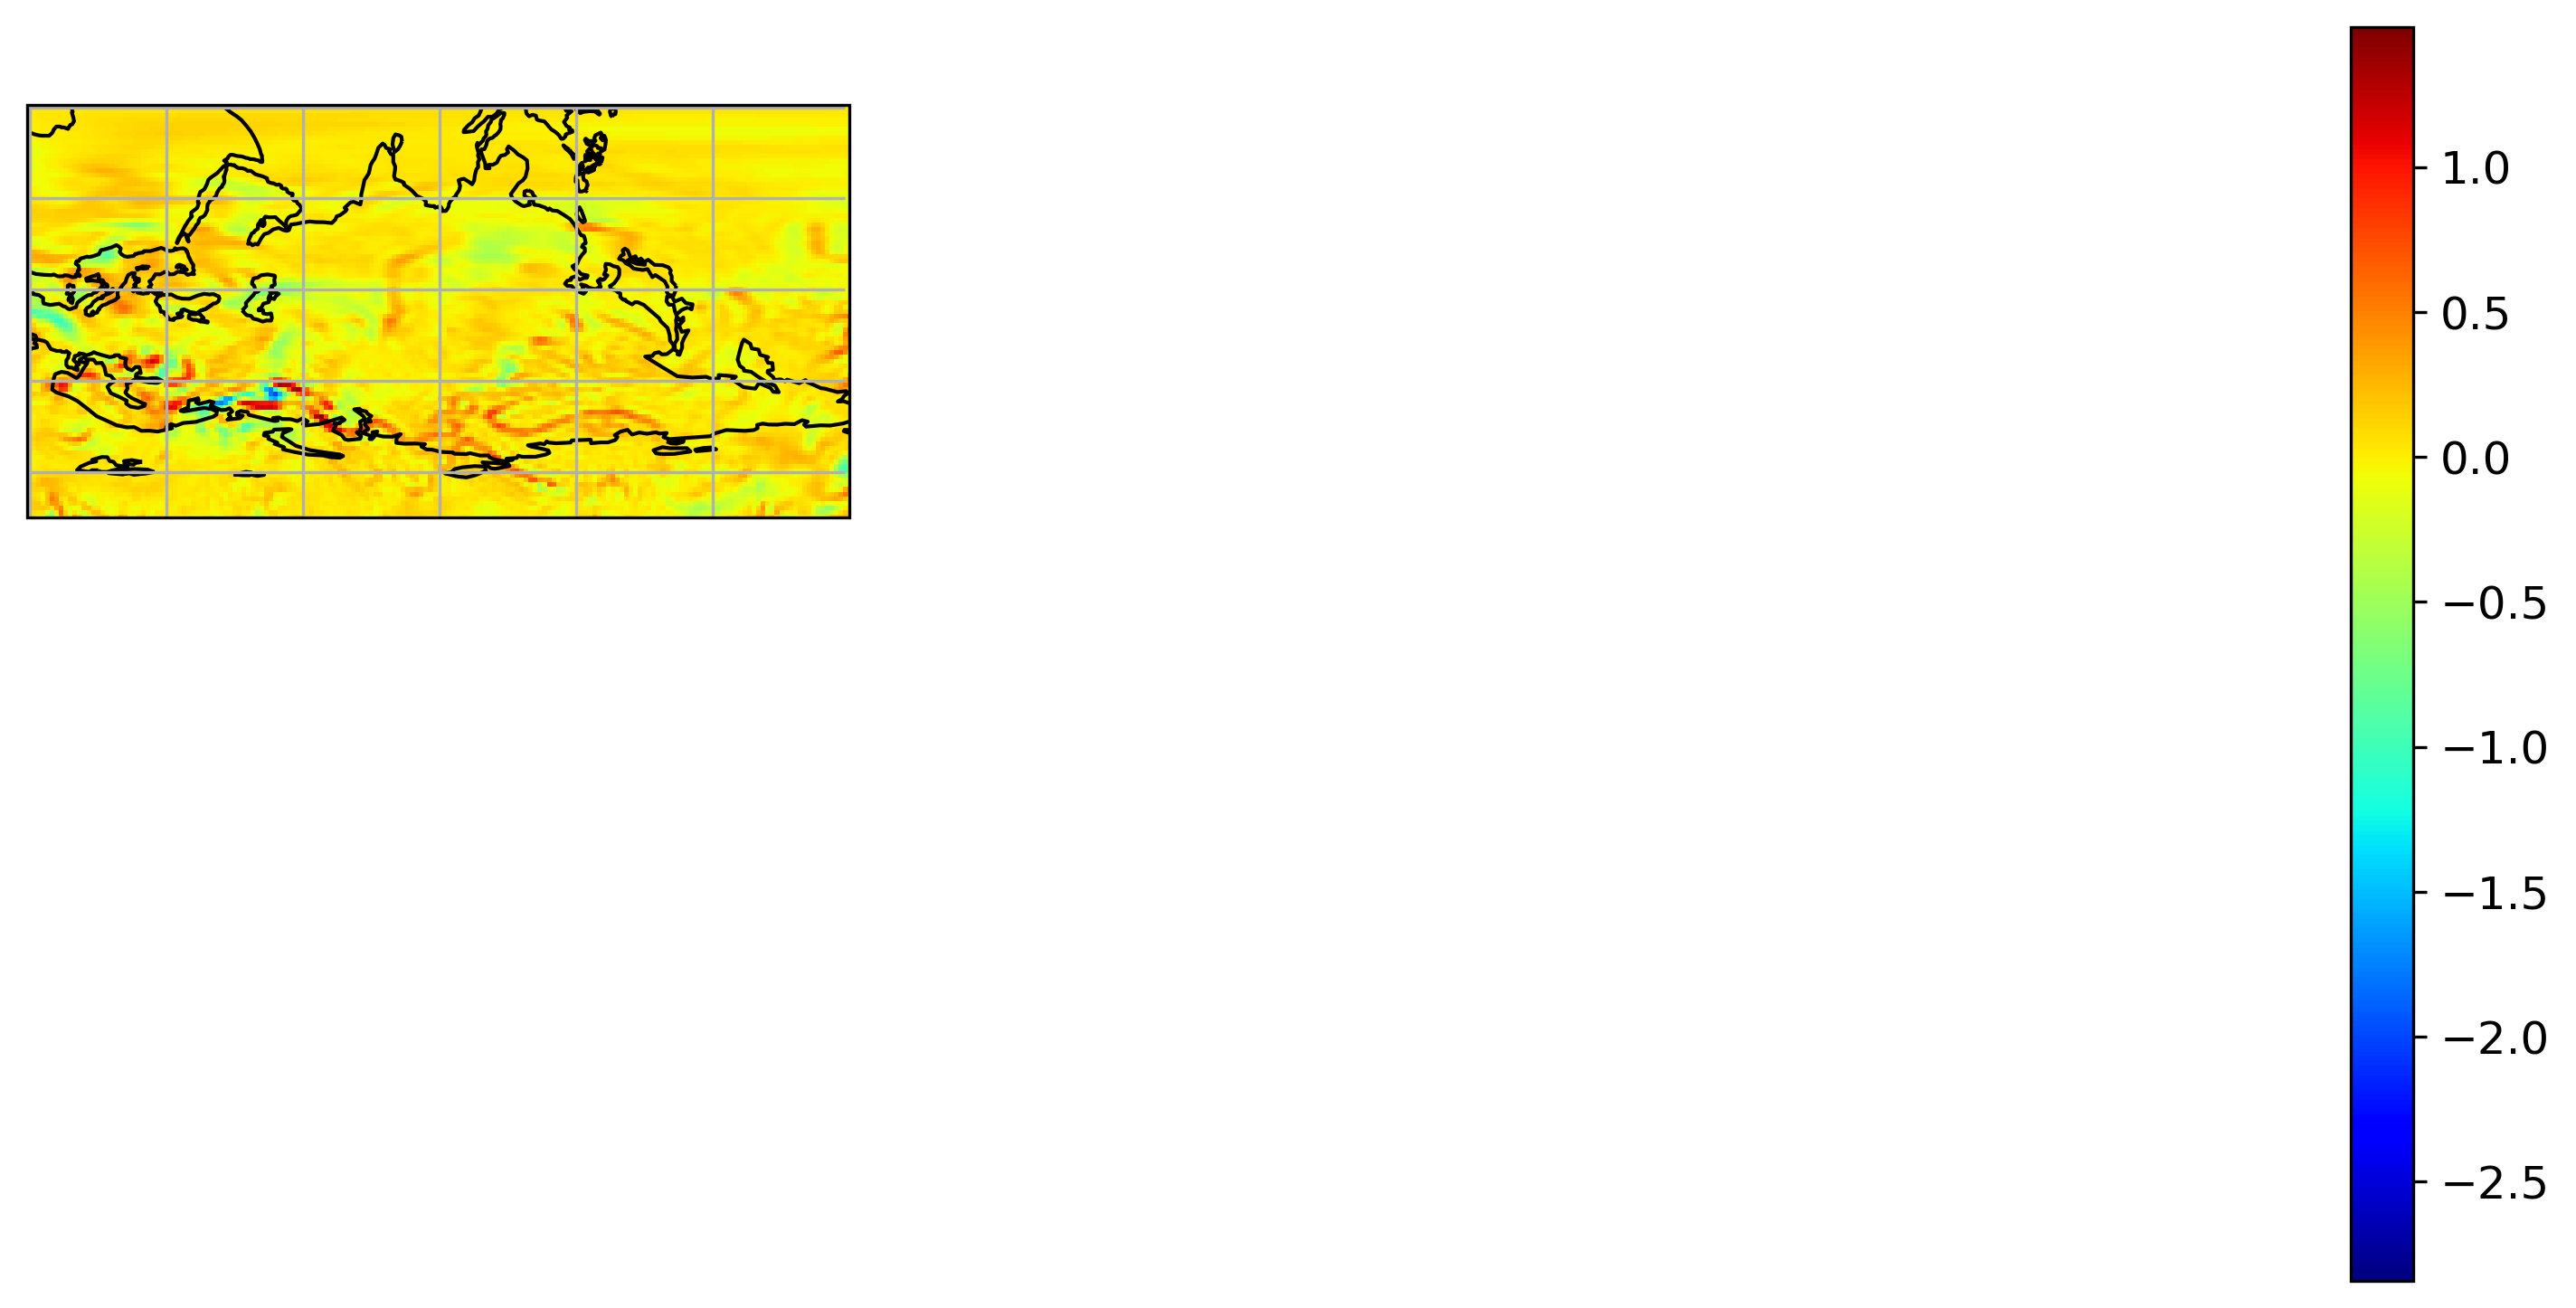

In [ ]:

plt.figure(dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines()
plt.imshow(ww[t, n, :, :], cmap='jet')
plt.colorbar()


**Q2**: **plot wind** **velocity** **at 850 hPa.**  you will need to use u and v compoments to make wind fields.

In [ ]:
plt.figure(dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines()
plt.imshow(vv[t, n, :, :], cmap='jet')
plt.colorbar()

After reading in the different variables we can start to have a look at the data.

a) Find out the domain of the data and how many different levels are present in the dataset.

A good way to have a look at your data is to plot it. The re-analysis data is presented in the netcdf file with a longitude from 0 to 360 degrees. As we are interested in Europe we want the data to be in the format with a longitude from -180 to 180 degrees.

In [ ]:
# The statement below enforces the plots to be put into this notebook, instead of in their own windows.
%pylab inline
pl.rcParams.update({'font.size': 12})          # Set the standard font size of the plots to 11pt.
pl.rcParams.update({'figure.figsize': [13,6]}) # Set the standard figure size.

t = -1
p_plot = 85000.                                # the pressure level which we want to plot
n = abs(p-p_plot).argmin()
# normalize the pressure levels and find the location of the p_plot value in the list of pressure levels

nroll = lon.size//2
lon = np.roll(lon, nroll)                      # np.roll: roll array elements along a given axis.
lon = np.where(lon>=180., lon-360., lon)       # change longitude to -180 to 180 degrees

T = np.roll(Temp[t,:,:,:], nroll, -1)          # numpy.roll(a, shift, axis=None)

Populating the interactive namespace from numpy and matplotlib


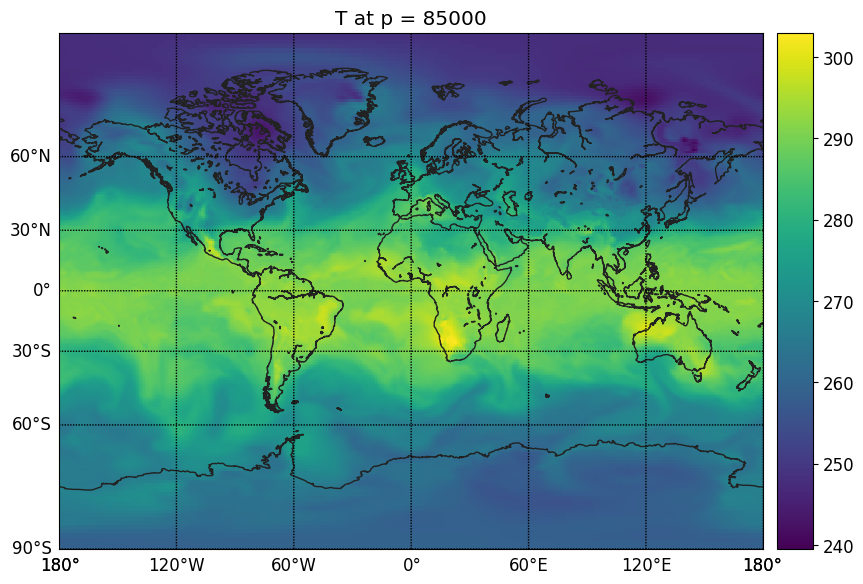

In [ ]:
m = Basemap(llcrnrlon=-180, llcrnrlat=-90, urcrnrlon=180, urcrnrlat=90, projection='mill', resolution='l')
#create a basemap with the latitudes, longitudes and projection you want to plot

# Convert lat/lon to map coordinates
lons, lats = m(*np.meshgrid(lon, lat))

# plot the variable T with a colorbar
m.pcolormesh(lons, lats, T[n,:,:])
m.colorbar()

# Draw coastlines
m.drawcoastlines(color='#222222')

# Draw parallels and meridians.
m.drawparallels(np.arange(-90.,90.,30.),labels=[1,0,0,0])
m.drawmeridians(np.arange(0.,360.,60.),labels=[0,0,0,1])

pl.title('T at p = {0}'.format(p[n]));         # plot title
pl.tight_layout()

b) Create a map only over Europe by changing the code

c) Plot temperature at the surface

We have now looked at temperature over a horizontal domain. But we can also plot temperature in the vertical.

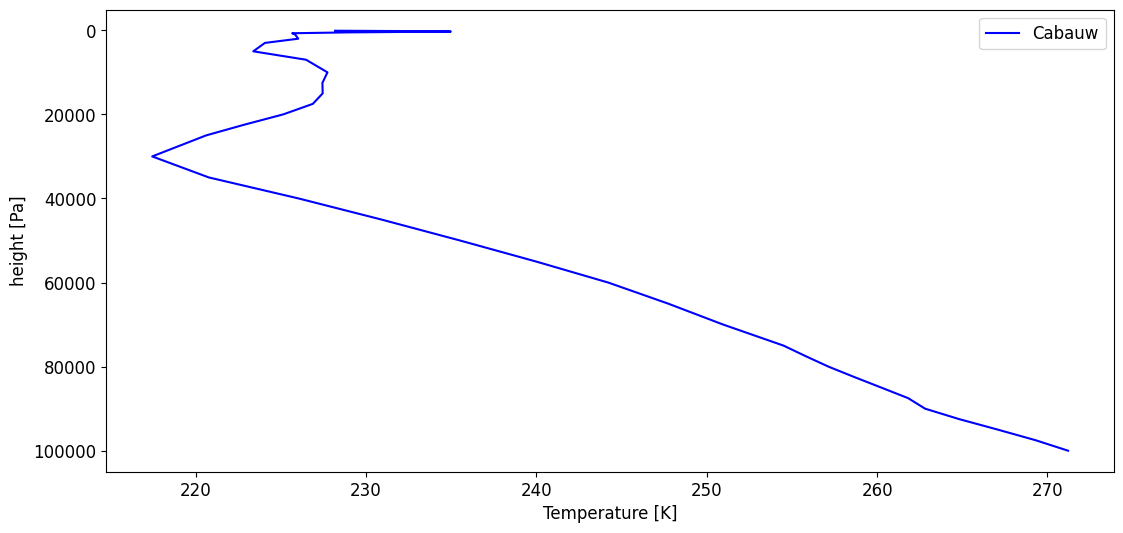

In [ ]:
# take vertical slice of temperature (at Cabauw 51.9653° N, 4.8979° E )
lon_plot = 4.8979
lat_plot = 51.9653
lon_n = abs(lon-lon_plot).argmin()
lat_n = abs(lat-lat_plot).argmin()

# plot figure
pl.figure()
plot(T[:,lat_n, lon_n],p, 'b', label= 'Cabauw')
pl.xlabel('Temperature [K]')                    # Assign title to x-axis
pl.ylabel('height [Pa]')                        # Assign title to y-axis
# invert yaxis as pressure coordinates go from high to low
pl.gca().invert_yaxis()
leg1 = legend(loc=1,ncol=1)                     # include legend

d) Include a vertical profile of a different location in the same plot

To asses and bewerk your data often loops are used to assign each element is a list. Here we show an example of a loop in python: We want to calculate the gradient in temperature between the different grid points.

In [ ]:
T_gradient_lon = np.zeros(T[n,:,:].shape)
for i in range(1,lon.size): # T [level, latitude, longitude]
    T_gradient_lon[:,i] =  T[n,:,i] - T[n,:,i-1]

T_gradient_lat = np.zeros(T[n,:,:].shape)
for j in range(lat.size):
    T_gradient_lat[j,] = T[n,j,:] - T[n,j-1,:]
    print(T_gradient_lat)

[[-10.94321347 -10.94321347 -10.94321347 ... -10.94321347 -10.94321347
  -10.94321347]
 [  0.           0.           0.         ...   0.           0.
    0.        ]
 [  0.           0.           0.         ...   0.           0.
    0.        ]
 ...
 [  0.           0.           0.         ...   0.           0.
    0.        ]
 [  0.           0.           0.         ...   0.           0.
    0.        ]
 [  0.           0.           0.         ...   0.           0.
    0.        ]]
[[-10.94321347 -10.94321347 -10.94321347 ... -10.94321347 -10.94321347
  -10.94321347]
 [ -0.39919123  -0.39343367  -0.3876761  ...  -0.41646393  -0.41070636
   -0.4049488 ]
 [  0.           0.           0.         ...   0.           0.
    0.        ]
 ...
 [  0.           0.           0.         ...   0.           0.
    0.        ]
 [  0.           0.           0.         ...   0.           0.
    0.        ]
 [  0.           0.           0.         ...   0.           0.
    0.        ]]
[[-10.94321347 -

In [ ]:
T_gradient_lat1 = np.diff(T[n,:,:], axis=0)
T_gradient_lon1 = np.diff(T[n,:,:], axis=1)
print(T_gradient_lat1)
print(T_gradient_lon1)

[[-0.0671716  -0.06333322 -0.05949485 ... -0.08060592 -0.07676754
  -0.07292917]
 [-0.05181809 -0.04797972 -0.04222215 ... -0.06333322 -0.05757566
  -0.05373728]
 [-0.09979781 -0.09212105 -0.09020186 ... -0.11323213 -0.10939375
  -0.10555537]
 ...
 [-1.09777589 -1.12464453 -1.15343236 ... -1.01333159 -1.04020023
  -1.06898806]
 [-0.5891909  -0.60454441 -0.61989792 ... -0.54504957 -0.56040308
  -0.5738374 ]
 [-0.10747456 -0.11323213 -0.11707051 ... -0.09212105 -0.09787862
  -0.10363619]]
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.00383838 0.00383838 0.00383838 ... 0.00383838 0.00383838 0.00383838]
 [0.00767675 0.00959594 0.00959594 ... 0.00767675 0.00959594 0.00767675]
 ...
 [0.02111107 0.01919189 0.02111107 ... 0.02111107 0.02111107 0.01919189]
 [0.00575757 0.00383838 0.00575757 ... 0.00575757 0.00575757 0.00575757]
 [0.         0.         0.         ... 0.         0.         0.        ]]


Now we have calculated the gradient of the temperature in both the x and the y direction.
Python also has an automatic function for this called np.gradient.
np.diff : Calculate the n-th discrete difference along given axis

`T_gradient_lat1 = np.diff(T[n,:,:], axis=0)`
T_gradient_lon1 = np.diff(T[n,:,:], axis=1)

e) Check if both methods have produces the same output.

f) Python also provides the function np.gradient. Find out what happens when you apply this function.

In [ ]:
T_gradient_lat2 = np.gradient(T[n,:,:], axis=0)
T_gradient_lon2 = np.gradient(T[n,:,:], axis=1)
print(T_gradient_lat2)
print(T_gradient_lon2)

[[-0.3991912315109687 -0.39343366567189264 -0.38767609983278817 ...
  -0.4164639290282821 -0.41070636318917764 -0.40494879735007316]
 [-0.3070701780853682 -0.30419139516581595 -0.3013126122462779 ...
  -0.3137873382309948 -0.3118681496179505 -0.3089893666984125]
 [-0.14201995736449646 -0.14010076875145216 -0.13914117444493002 ...
  -0.1448987402840345 -0.14393914597752655 -0.1429795516710044]
 ...
 [-0.638130213833648 -0.6419685910597366 -0.6458069682857968 ...
  -0.6189383277033471 -0.6266150821554675 -0.6323726479945719]
 [0.2859591033420088 0.2811611318094265 0.27636316027684416 ...
  0.30227220655280007 0.2965146407136956 0.2917166691811133]
 [0.5105041710669411 0.5066657938409094 0.5028274166148208 ...
  0.5181809255191183 0.516261736906074 0.5124233596799854]]
[[0.0 0.0 0.0 ... 0.0 0.0 0.0]
 [0.005757565839076051 0.005757565839090262 0.005757565839104473 ...
  0.005757565839104473 0.005757565839104473 0.005757565839104473]
 [0.005757565839104473 0.005757565839090262 0.00479797153